In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Prelim_sizing_database_revised.csv", sep = ",")
df = df.replace("None", np.nan) # replacing all the None strings to NaN (better for pandas apparently)
df = df.replace("#VALUE!", np.nan)

# converting numerical columns from strings to floats
columns = list(df)
for i in columns[2:8]:
    df[f'{i}'] = pd.to_numeric(df[f'{i}'])

In [4]:
mean_squared_error = lambda yreal, ypred: sum((yreal[i] - ypred[i]) ** 2 for i in range(len(yreal))) / len(yreal)
rmse = lambda yreal, ypred: mean_squared_error(yreal, ypred) ** 0.5

<AxesSubplot:xlabel='TOM', ylabel='Range'>

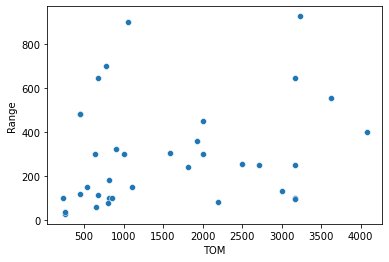

In [5]:
# plotting mtom with range
mass_range = df[['TOM', 'Range']].dropna()
mass_range_filt = mass_range[(mass_range.TOM <5000) & (mass_range.Range < 1000)]
sns.scatterplot(data = mass_range_filt, x = 'TOM', y = 'Range')

<AxesSubplot:xlabel='TOM', ylabel='People'>

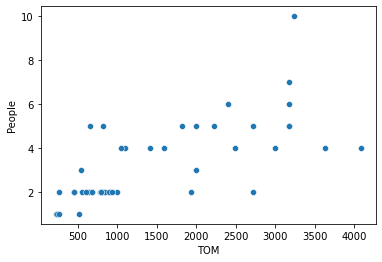

In [3]:
# plotting passengers and weight

pass_mass = df[['People', 'TOM']].dropna()
pass_mass_filt = pass_mass[(pass_mass.TOM < 5000) & (pass_mass.People > 0)]
sns.scatterplot(data = pass_mass_filt, x = 'TOM', y = 'People')

<AxesSubplot:xlabel='Range', ylabel='Speed'>

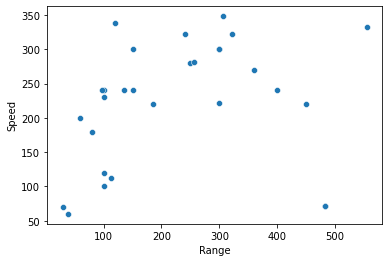

In [24]:
# plotting passengers Range vs Speed
range_speed = df[(df.TOM < 5000) & (df.People > 0)]
range_speed = range_speed[['Range', 'Speed']].dropna()
range_speed_filt = range_speed[(range_speed.Speed < 500) & (range_speed.Range < 600)]
sns.scatterplot(data = range_speed_filt, x = 'Range', y = 'Speed')

RMSE: 222.61168656852317
Line equation is: y = 0.8777277792198354x + -129.40436022777322


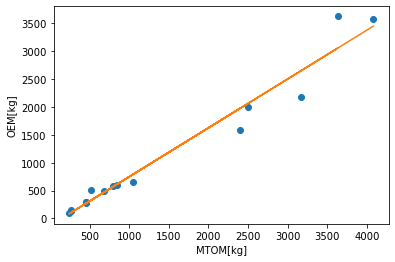

In [13]:
# plotting MTOM with OEM
TOM_OEM = df[['TOM', 'OEM']].dropna()

x = np.array(TOM_OEM.iloc[:,0])
y = np.array(TOM_OEM.iloc[:,1])

m_1, b_1 = np.polyfit(x, y, 1)

print(f'RMSE: {rmse(y, m_1*x+b_1)}')
print(f'Line equation is: y = {m_1}x + {b_1}')
plt.plot(x , y, 'o')
plt.plot(x,m_1*x+b_1)
plt.xlabel('MTOM[kg]')
plt.ylabel('OEM[kg]')
plt.savefig('MTOMvsOEM.jpg')
plt.show()

RMSE: 745.5742015443748
Line equation is: y = 3.8690174564620694x + 92.84274814780835


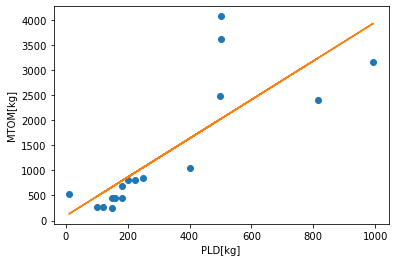

In [12]:
# plotting MTOM with payload
TOM_PLD = df[['TOM', 'Payload']].dropna()

y = np.array(TOM_PLD.iloc[:,0])
x = np.array(TOM_PLD.iloc[:,1])

m_2, b_2 = np.polyfit(x, y, 1)

print(f'RMSE: {rmse(y, m_2*x+b_2)}')
print(f'Line equation is: y = {m_2}x + {b_2}')
plt.plot(x , y, 'o')
plt.plot(x,m_2*x+b_2)
plt.ylabel('MTOM[kg]')
plt.xlabel('PLD[kg]')
plt.savefig('PLDvsMTOM.png')
plt.show()

In [20]:
# estimating take-off mass based on payload mass
# the same but for operational empty mass based on take-off mass
req_pld = 5*95
TOM_est = m_2*req_pld + b_2
OEM_est = m_1 * TOM_est + b_1
print(f'Take-off Mass estimate: {TOM_est = } kg,  Operational Empty Mass estimate: {OEM_est = } kg')

Take-off Mass estimate: TOM_est = 1930.6260399672913 kg,  Operational Empty Mass estimate: OEM_est = 1565.1597463367025 kg


In [17]:
# determining design cruise altitude

cities_alt = np.array([929, 837, 810, 802, 718, 700, 698, 695, 686, 
                       683, 667, 665, 664, 660, 652, 649, 623, 600, 
                       594, 580, 574, 568, 542, 519, 518, 516])

avg_alt = cities_alt.mean()
avg_alt += 450
print(f'Design cruise altitude is: {np.round(avg_alt,0)} m')

Design cruise altitude is: 1110.0 m


In [26]:
rho = lambda h: 1.225 * pow(1 - 0.0065 * h / 288.15, 9.81 / (0.0065 * 287) - 1)

Area = lambda WoS, W: W / WoS

design_cruise_speed = lambda rhoair, CL, WoS: (WoS * 2 / (rhoair * CL)) ** 0.5

print(f'{rho(avg_alt) = } kgm^-3')

rho(avg_alt) = 1.099650576194018 kgm^-3


In [27]:
design_dive_speed = lambda Vc: 1.25 * Vc # MOC eVTOL

AspectRatio = lambda S, b: b ** 2 / S 